## Exploratory Data Analysis — Fraudulent Transaction Detection

This notebook picks up where `Dataset_cleaning.ipynb` left off, working from the fully cleaned dataset to explore how individual features relate to the target variable, `is_fraud`. The goal is to identify which signals carry genuine predictive value — and to build the intuition needed to justify feature engineering choices — before any modelling takes place.

In [7]:
# importing libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
cleaned_cust_trans_data = pd.read_csv(r'C:/Users/oluwa/OneDrive/Desktop/Fraudulent_transaction_Detection_for_a_FinTech_Company/Finlora_Dataset/artifacts/Cleaned_Data.csv')

In [4]:
for col in cleaned_cust_trans_data.select_dtypes(include='object').columns:
    if 'unknown' in cleaned_cust_trans_data[col].astype(str).str.lower().unique():
        count = (cleaned_cust_trans_data[col].astype(str).str.lower() == 'unknown').sum()
        print(f"{col}: {count} 'unknown' values")

home_country: 32 'unknown' values
channel: 36 'unknown' values
ip_country: 30 'unknown' values
kyc_tier: 28 'unknown' values


In [5]:
print(cleaned_cust_trans_data['kyc_tier'].value_counts(dropna=False))
print(cleaned_cust_trans_data['ip_country'].value_counts(dropna=False))
print(cleaned_cust_trans_data['home_country'].value_counts(dropna=False))
print(cleaned_cust_trans_data['channel'].value_counts(dropna=False))

kyc_tier
standard    7786
enhanced    1802
low         1034
unknown       28
Name: count, dtype: int64
ip_country
US         6610
UK         2333
CA         1677
unknown      30
Name: count, dtype: int64
home_country
US         7474
UK         1981
CA         1163
unknown      32
Name: count, dtype: int64
channel
Mobile     6055
Web        3608
Atm         951
Unknown      36
Name: count, dtype: int64


In [6]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1,
    palette="Spectral"
    )

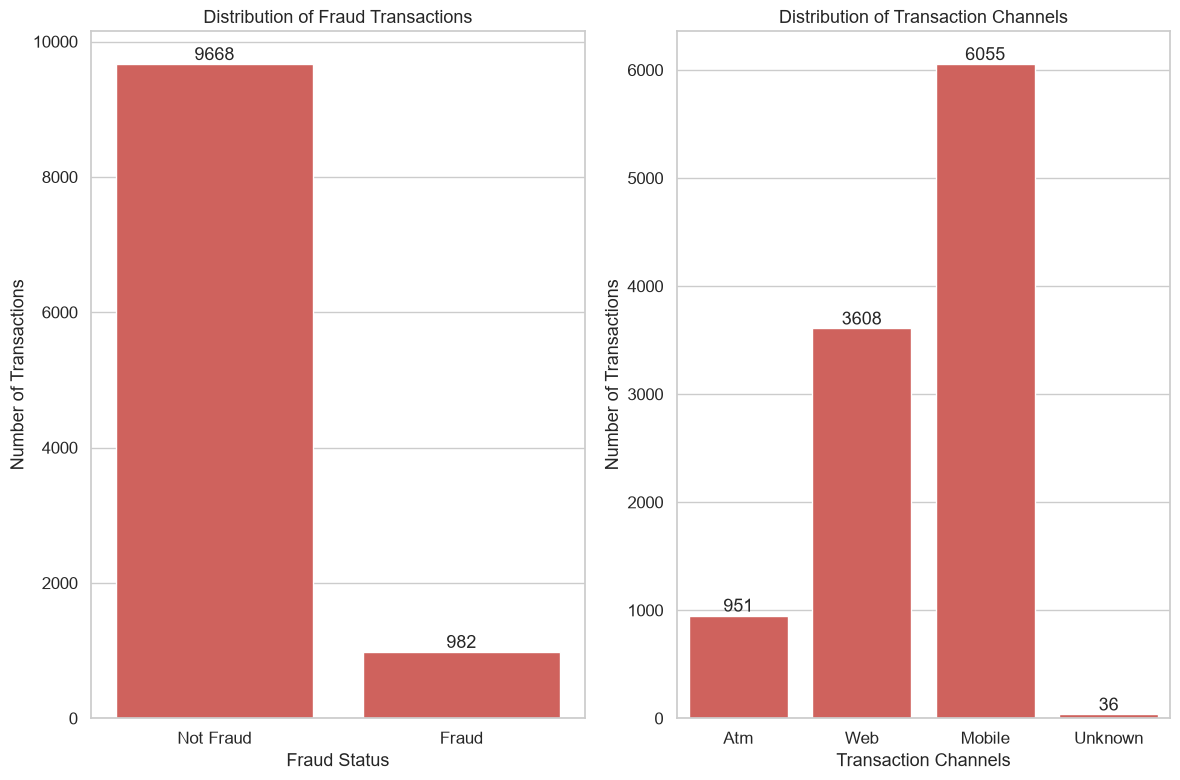

In [7]:
# Distribution of Fraud Transactions and Transaction Channels

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# Plotting the distribution of fraudulent transactions
sns.countplot(data=cleaned_cust_trans_data, x='is_fraud', ax=axes[0],)
axes[0].set_title('Distribution of Fraud Transactions')
axes[0].set_xlabel('Fraud Status')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Fraud', 'Fraud'])
axes[0].bar_label(axes[0].containers[0])


# Plotting the distribution of transaction channels
sns.countplot(data=cleaned_cust_trans_data, x='channel', ax=axes[1])
axes[1].set_title('Distribution of Transaction Channels')
axes[1].set_xlabel('Transaction Channels')
axes[1].set_ylabel('Number of Transactions')
axes[1].bar_label(axes[1].containers[0])

plt.tight_layout()
plt.show()

#### Distribution of Fraud Transactions and Transaction Channels

The two charts above give a first visual look at the class balance of the target variable and how transactions are spread across channels, following the cleaning steps applied earlier.

**Fraud distribution:** confirms the class imbalance already established numerically — the cleaned dataset has 9,668 legitimate transactions (90.78%) against 982 fraud cases (9.22%). Visually, the "Fraud" bar is a small fraction of the "Not Fraud" bar, reinforcing that any model built on this data will need to account for this imbalance (e.g. through class weighting, resampling, or an appropriate choice of evaluation metric rather than just accuracy).

**Channel distribution:** "Mobile" is the dominant channel, followed by "Web", with "Atm" the smallest of the three legitimate channels. "Unknown" — the residual category created during cleaning for channel values that couldn't be resolved to a real label — sits at just 36 transactions (~0.3% of the dataset), visually near-invisible next to the other bars even with value labels added to make its count readable. This is consistent with the earlier decision to preserve unresolved values as an explicit "unknown" category rather than force them into one of the three real channels, so the chart accurately reflects that a small residual of channel data remains genuinely unresolved rather than hiding it.

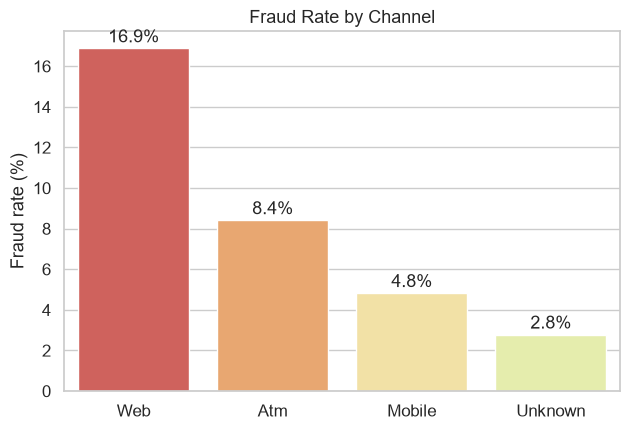

In [8]:
# Fraudulent transactions across different channels.


channel_rate = (cleaned_cust_trans_data.groupby('channel')['is_fraud'].mean() * 100).sort_values(ascending=False).reset_index()

plt.figure(figsize=(6.5, 4.5))
sns.barplot(data=channel_rate, x='channel', y='is_fraud', hue='channel', legend=False)
plt.title('Fraud Rate by Channel')
plt.ylabel('Fraud rate (%)')
plt.xlabel('')
for i, v in enumerate(channel_rate['is_fraud']):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

##### Web transactions are fraudulent 16.9% of the time, more than three times the rate of mobile (4.8%) and twice that of ATM (8.4%). In short, the channel itself contains signals about the likelihood of a transaction being fraudulent that is likely explained by the inherent security properties of the different channels. A mobile app session will always be attached to a verified device (with some caveats on rooted devices, etc.), whereas a web session may be initiated from an unverified or completely different device/location. As such, the channel is a useful categorical feature for a model, but there may be value in exploring channel-specific thresholds or additional verification steps for web transactions as a fraud prevention tool.

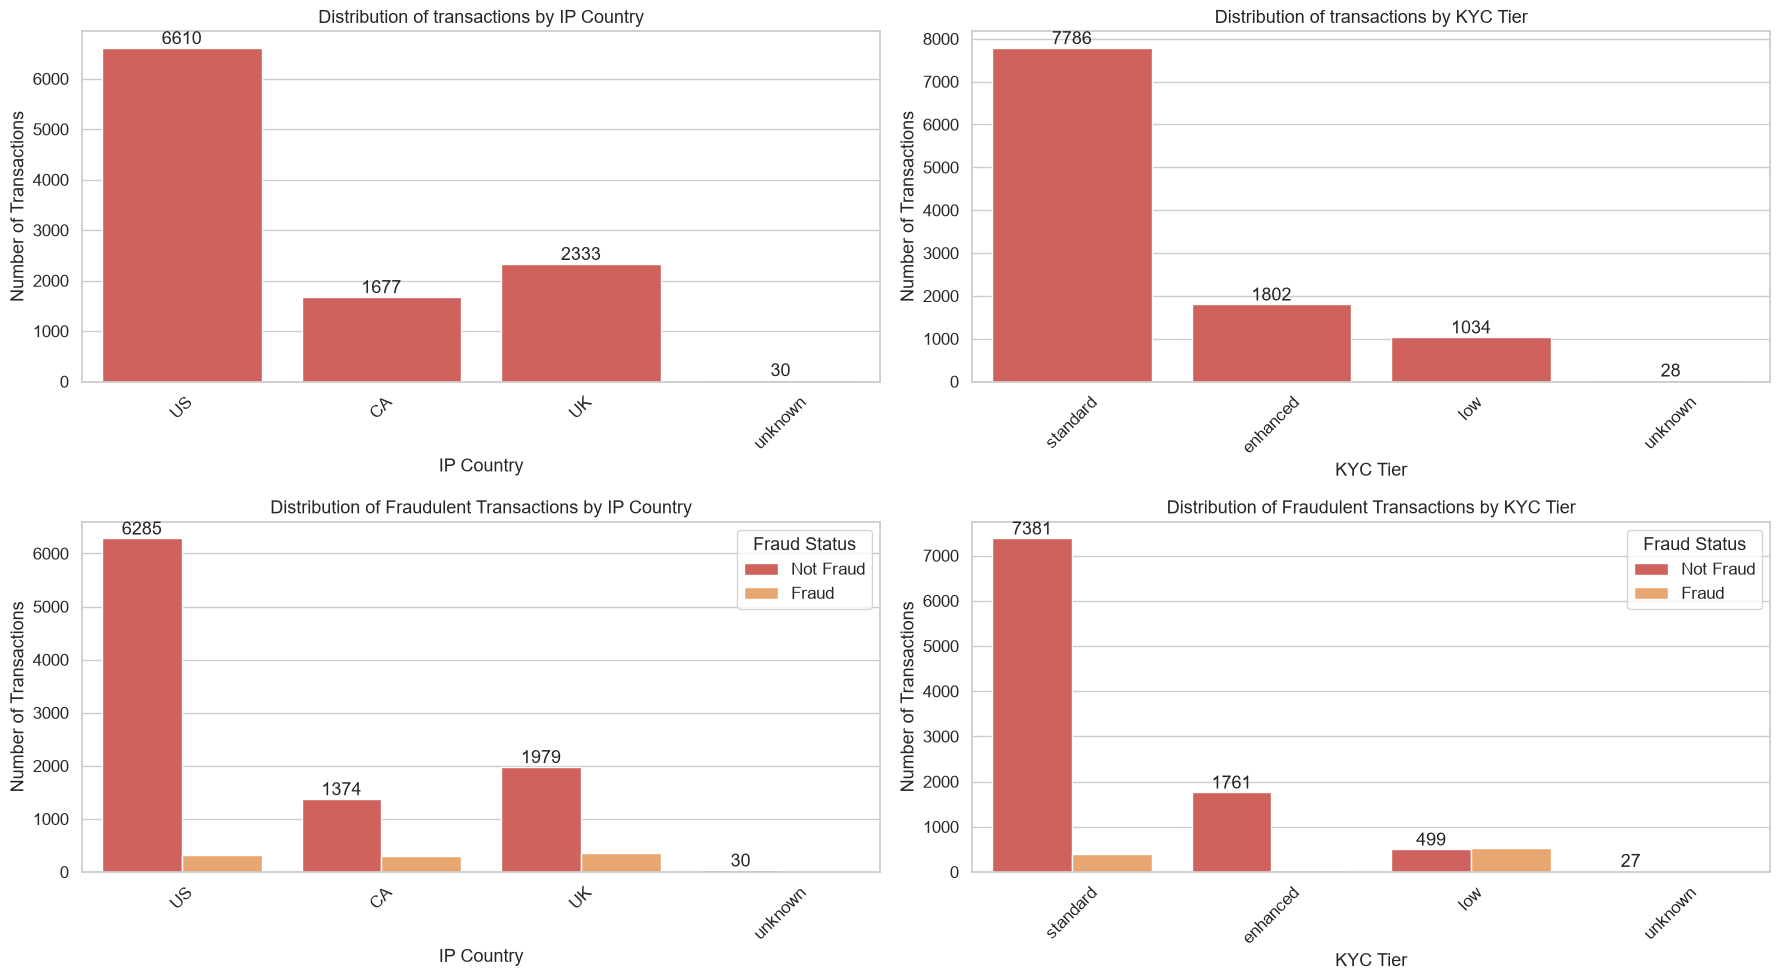

In [ ]:
# Exploring the relationships between IP Country, KYC Tier, and Fraudulent Transactions

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1.  IP Country Distribution
sns.countplot(
    data=cleaned_cust_trans_data, 
    x='ip_country', 
    ax=axes[0, 0])
axes[0, 0].set_title('Distribution of transactions by IP Country')
axes[0, 0].set_xlabel('IP Country')
axes[0, 0].set_ylabel('Number of Transactions')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].bar_label(axes[0, 0].containers[0])

# 2. KYC Tier Distribution
sns.countplot(
    data=cleaned_cust_trans_data, 
    x='kyc_tier', 
    ax=axes[0, 1])
axes[0, 1].set_title('Distribution of transactions by KYC Tier')
axes[0, 1].set_xlabel('KYC Tier')
axes[0, 1].set_ylabel('Number of Transactions')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].bar_label(axes[0, 1].containers[0])

# 3. IP Country vs Fraudulent Transactions
sns.countplot(
    data=cleaned_cust_trans_data, 
    x='ip_country', 
    hue='is_fraud',


    ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Fraudulent Transactions by IP Country')
axes[1, 0].set_xlabel('IP Country')
axes[1, 0].set_ylabel('Number of Transactions')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])
axes[1, 0].bar_label(axes[1, 0].containers[0])

# 4. KYC Tier vs Fraudulent Transactions
sns.countplot(
    data=cleaned_cust_trans_data, 
    x='kyc_tier', 
    hue='is_fraud',
    ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Fraudulent Transactions by KYC Tier')
axes[1, 1].set_xlabel('KYC Tier')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Fraud Status', labels=['Not Fraud', 'Fraud'])
axes[1, 1].bar_label(axes[1, 1].containers[0])

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

#### Fraud Rate by IP Country and KYC Tier

Moving from raw counts (top row) to fraud rate within each category (bottom row) surfaces two of the strongest categorical signals found so far:

**IP Country:** US dominates by volume (6,610 transactions) but has the lowest fraud rate of the three real countries, at **~4.9%** (325 of 6,610). CA and UK — despite being smaller in volume — run considerably hotter: **~18.1%** for CA (303 of 1,677) and **~15.2%** for UK (354 of 2,333). A transaction originating from CA or UK is roughly 3–4x more likely to be fraudulent than one from US, even though US carries the bulk of volume.

**KYC Tier:** this is the standout signal. standard sits around **5.2%** fraud (405 of 7,786) and enhanced — the more thoroughly verified tier — is lower still, at **~2.3%** (41 of 1,802), matching the intuition that stronger verification correlates with lower risk. low tier breaks that pattern dramatically: **~51.7%** of low-tier transactions are fraudulent (535 of 1,034) — the orange (fraud) bar is nearly as tall as the legitimate one, unlike every other category. kyc_tier, specifically the low category, is one of the strongest individual predictors identified in this entire analysis.



C:\Users\oluwa\AppData\Local\Temp\ipykernel_23432\2356217386.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\oluwa\AppData\Local\Temp\ipykernel_23432\2356217386.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\oluwa\AppData\Local\Temp\ipykernel_23432\2356217386.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


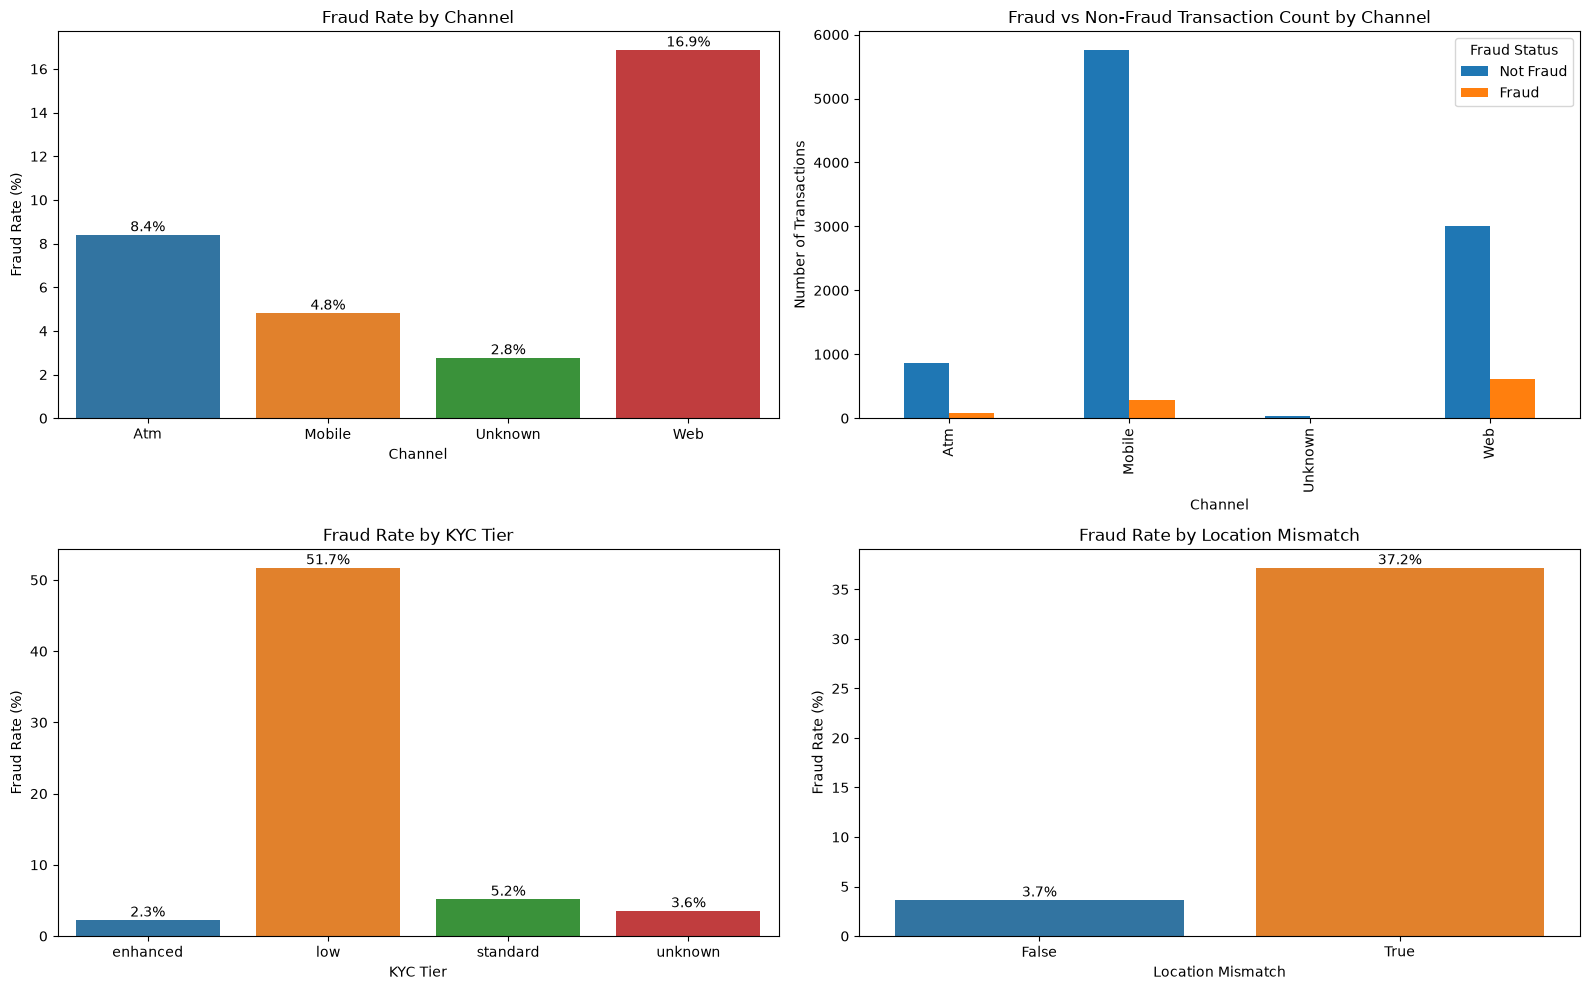

In [13]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Fraud Rate by Channel

channel_fraud_rate = cleaned_cust_trans_data.groupby('channel')['is_fraud'].mean().reset_index()
channel_fraud_rate['is_fraud'] = channel_fraud_rate['is_fraud'] * 100

sns.barplot(
    data=channel_fraud_rate,
    x='channel',
    y='is_fraud',
    ax=axes[0, 0],
    palette='tab10'
)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.1f%%')

axes[0, 0].set_title('Fraud Rate by Channel')
axes[0, 0].set_xlabel('Channel')
axes[0, 0].set_ylabel('Fraud Rate (%)')


# 2. Fraud vs Non-Fraud transaction count by channel

channel_transaction_counts = (
    cleaned_cust_trans_data.groupby('channel')['is_fraud']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)

channel_transaction_counts = channel_transaction_counts.rename(
    columns={0: 'Not Fraud', 1: 'Fraud'}
    )


channel_transaction_counts.plot(
    x='channel',
    y=['Not Fraud', 'Fraud'],
    kind='bar',
    ax=axes[0, 1],
)

axes[0, 1].set_title('Fraud vs Non-Fraud Transaction Count by Channel')
axes[0, 1].set_xlabel('Channel')
axes[0, 1].set_ylabel('Number of Transactions')
axes[0, 1].legend(title='Fraud Status')


# 3. Fraud Rate by KYC Tier

kyc_fraud_rate = cleaned_cust_trans_data.groupby('kyc_tier')['is_fraud'].mean().reset_index()
kyc_fraud_rate['is_fraud'] = kyc_fraud_rate['is_fraud'] * 100

sns.barplot(
    data=kyc_fraud_rate,
    x='kyc_tier',
    y='is_fraud',
    ax=axes[1, 0],
    palette='tab10'
)
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='%.1f%%')


axes[1, 0].set_title('Fraud Rate by KYC Tier')
axes[1, 0].set_xlabel('KYC Tier')
axes[1, 0].set_ylabel('Fraud Rate (%)') 



#4. Fraud rate by Location Mismatch (IP Country vs Home Country)
location_mismatch_fraud_rate = (
    cleaned_cust_trans_data.groupby('location_mismatch')['is_fraud']
    .mean()
    .reset_index()
    )

location_mismatch_fraud_rate['is_fraud'] = location_mismatch_fraud_rate['is_fraud'] * 100
sns.barplot(
    data=location_mismatch_fraud_rate,
    x='location_mismatch',
    y='is_fraud',
    ax=axes[1, 1],
    palette='tab10'
)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='%.1f%%')

axes[1, 1].set_title('Fraud Rate by Location Mismatch')
axes[1, 1].set_xlabel('Location Mismatch')
axes[1, 1].set_ylabel('Fraud Rate (%)')


plt.tight_layout()
plt.show()




#### Fraud Rate by Channel & KYC Tier (Cross-Check) and Location Mismatch

The top-left and bottom-left panels reproduce the channel and kyc_tier fraud rates already established above — included here for a side-by-side comparison against volume and against the new location_mismatch signal, rather than as new findings.

**Fraud vs. non-fraud counts by channel (top-right):** Mobile carries the largest *absolute number of fraud cases despite having the lowest fraud rate, simply because it's by far the highest-volume channel. This is a useful reminder that rate and volume tell different parts of the story — Web is the riskiest channel per-transaction, but  mobile fraud still needs monitoring at scale given its sheer volume.

**Fraud rate by location mismatch (bottom-right):** this is one of the largest effects in the whole dataset. When ip_country matches home_country (False), the fraud rate is a low **3.7%**. When they don't match (True), it jumps to **37.2%** — like a 10X increase. This strongly validates location_mismatch as an engineered feature: a transaction originating from somewhere other than the customer's registered country is a major red flag, consistent with account-takeover or unauthorized-access patterns where the fraudster isn't physically where the legitimate customer is registered.

### Transaction Velocity and Fraud Risk

Transaction velocity — how many transactions a customer has made in a recent window — is a classic fraud signal: a sudden burst of activity often indicates a compromised account being drained quickly, rather than normal customer behaviour. The charts below test this intuition against both a 1-hour and a 24-hour window.

C:\Users\oluwa\AppData\Local\Temp\ipykernel_23432\834692784.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
C:\Users\oluwa\AppData\Local\Temp\ipykernel_23432\834692784.py:34: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


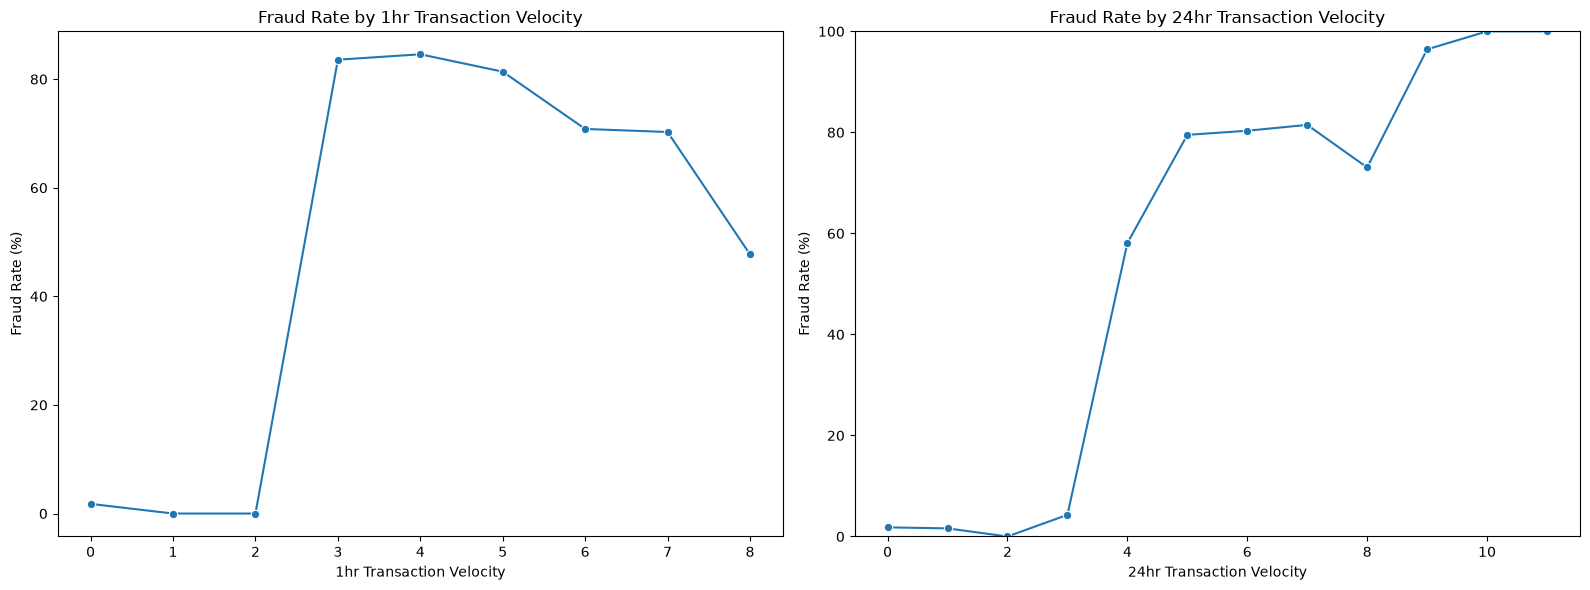

In [18]:
# Investigating the relationship between transaction velocity and fraud status

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Fraud rate by 1hr transaction velocity
txn_velocity_1hr_fraud_rate = (
    cleaned_cust_trans_data.groupby('txn_velocity_1h')['is_fraud']
    .mean()
    .reset_index()
)
txn_velocity_1hr_fraud_rate['is_fraud'] = txn_velocity_1hr_fraud_rate['is_fraud'] * 100

sns.lineplot(
    data=txn_velocity_1hr_fraud_rate,
    x='txn_velocity_1h',
    y='is_fraud',
    marker='o',
    ax=axes[0],
    palette='tab10'
)

axes[0].set_title('Fraud Rate by 1hr Transaction Velocity')
axes[0].set_xlabel('1hr Transaction Velocity')
axes[0].set_ylabel('Fraud Rate (%)')

# 2. Fraud rate by 24hr transaction velocity
txn_velocity_24hr_fraud_rate = (
    cleaned_cust_trans_data.groupby('txn_velocity_24h')['is_fraud']
    .mean()
    .reset_index()
)
txn_velocity_24hr_fraud_rate['is_fraud'] = txn_velocity_24hr_fraud_rate['is_fraud'] * 100

sns.lineplot(
    data=txn_velocity_24hr_fraud_rate,
    x='txn_velocity_24h',
    y='is_fraud',
    marker='o',
    ax=axes[1],
    palette='tab10'
)

axes[1].set_title('Fraud Rate by 24hr Transaction Velocity')
axes[1].set_xlabel('24hr Transaction Velocity')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

#### The line charts above show a sharp, threshold-like relationship between velocity and fraud 

**1-hour velocity:** fraud rate sits near **0%** for 0–2 transactions in the past hour, then jumps abruptly to **about 83–85%** at 3–5 transactions, before tapering off toward **about 48%** at 8. The jump between 2 and 3 transactions is the critical threshold — crossing it is associated with an enormous, near-instant shift in fraud likelihood.

**24-hour velocity:** shows a similar pattern, shifting slightly later — fraud rate stays low (under about 4%) through 0–3 transactions, then climbs steadily from **about 58%** at 4 transactions up to **100%** by 10–11.

##### Both patterns support velocity as a strong, threshold-based fraud signal rather than a purely linear one — a customer crossing a small number of transactions in a short window is a meaningfully different risk profile than one below it. This directly motivates engineering a binary "velocity spike" feature (e.g. flagging 1-hour velocity ≥ 3) rather than relying on the model to discover the threshold purely from the raw count, especially given how sharply the relationship breaks rather than curves.

C:\Users\oluwa\AppData\Local\Temp\ipykernel_30368\3103207888.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


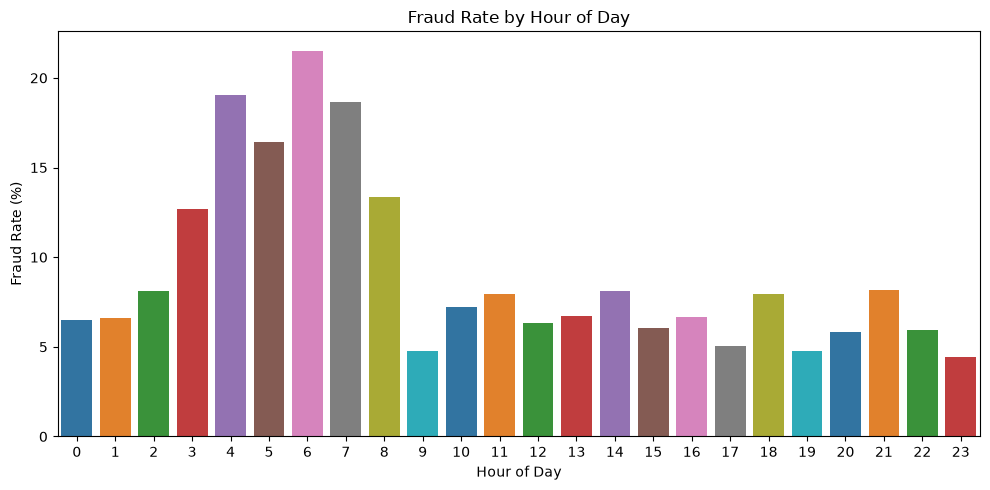

In [21]:
# Transaction count distribution across the different hours of the day and days of the week.

cleaned_cust_trans_data['timestamp'] = pd.to_datetime(cleaned_cust_trans_data['timestamp'])
cleaned_cust_trans_data['hour'] = cleaned_cust_trans_data['timestamp'].dt.hour
cleaned_cust_trans_data['day_of_week'] = cleaned_cust_trans_data['timestamp'].dt.day_of_week
cleaned_cust_trans_data['is_weekend'] = (cleaned_cust_trans_data['day_of_week'] >= 5).astype(int)
cleaned_cust_trans_data['month'] = cleaned_cust_trans_data['timestamp'].dt.month

# Fraud rate by hour of day
fraud_rate_by_hour = (
    cleaned_cust_trans_data.groupby('hour')['is_fraud']
    .mean()
    .reset_index()
)
fraud_rate_by_hour['is_fraud'] = fraud_rate_by_hour['is_fraud'] * 100

#Plot
plt.figure(figsize=(10,5))

sns.barplot(
    data=fraud_rate_by_hour,
    x='hour',
    y='is_fraud',
    palette='tab10'
)

plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour of Day')


plt.tight_layout()
plt.show()

#### The chart shows that fraudulent transactions cluster heavily in the early morning hours.

##### Fraud rate is elevated from roughly **hour 3 through hour 8** — peaking at **21.5%** at 6am, with 4am (19.1%), 5am (16.4%), 7am (18.7%), and 8am (13.4%) all well above the rest of the day. Every other hour sits in a tighter, lower band (roughly 4.5%–8.1%).

##### These are typically low-activity hours for genuine customers (most people aren't transacting at 4–6am), so both the reduced legitimate volume at these hours and fraud specifically targeting quieter windows (to reduce the chance of a customer noticing and intervening in real time) plausibly combine to produce this spike. This motivates a threshold-based late_night_hours feature flagging this specific window, rather than treating hour only as a raw feature.

C:\Users\oluwa\AppData\Local\Temp\ipykernel_30368\2588274565.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


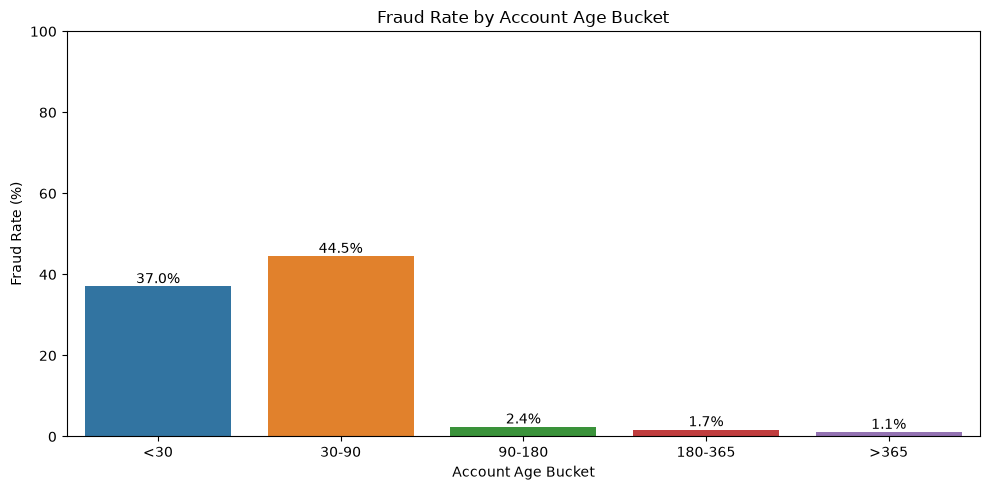

In [24]:
# Creating  account age buckets

cleaned_cust_trans_data['account_age_bucket'] = pd.cut(
    cleaned_cust_trans_data['account_age_days'],
    bins=[0, 30, 90, 180, 365, 2000],
    labels=['<30', '30-90', '90-180', '180-365', '>365']
)

# Calculating fraud rate by account age bucket

fraud_rate_by_account_age = (
    cleaned_cust_trans_data.groupby('account_age_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
)
fraud_rate_by_account_age['is_fraud'] = fraud_rate_by_account_age['is_fraud'] * 100


plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=fraud_rate_by_account_age,
    x='account_age_bucket',
    y='is_fraud',
    palette='tab10'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate (%)')
plt.ylim(0, 100)
plt.title('Fraud Rate by Account Age Bucket')

plt.tight_layout()
plt.show()






### A

C:\Users\oluwa\AppData\Local\Temp\ipykernel_30368\3967374417.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\oluwa\AppData\Local\Temp\ipykernel_30368\3967374417.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\oluwa\AppData\Local\Temp\ipykernel_30368\3967374417.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


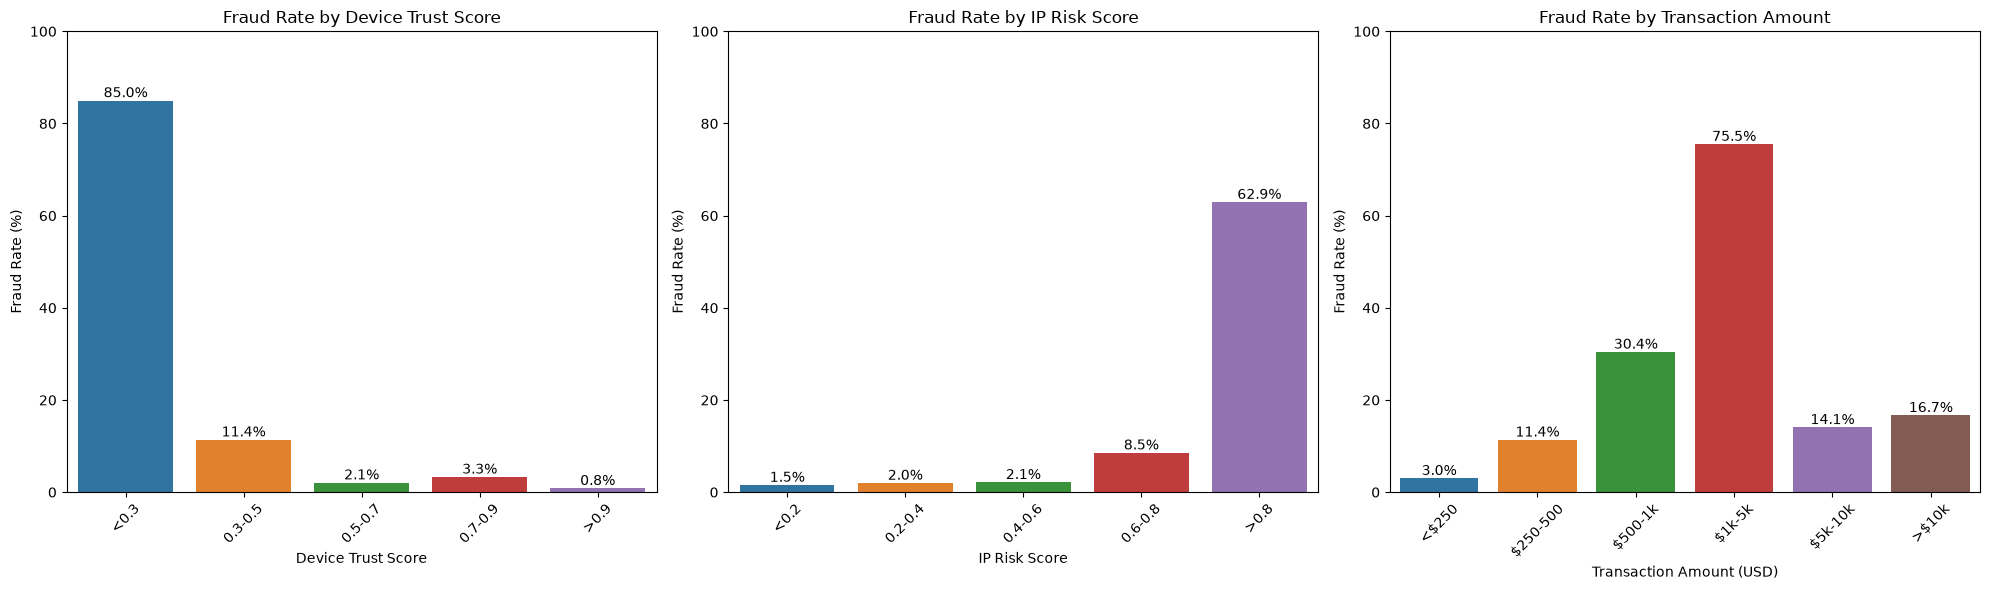

In [18]:
# Fraud rate by device trust score, ip risk score and transaction amount

fig, axes = plt.subplots(1, 3, figsize=(20, 6))


# 1. Fraud Rate by Device Trust Score

cleaned_cust_trans_data['device_trust_score_bucket'] = pd.cut(
    cleaned_cust_trans_data['device_trust_score'],
    bins=[0, 0.3, 0.5, 0.7, 0.9, 1.0],
    labels=['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', '>0.9'],
    include_lowest=True
)

Fraud_rate_by_device_trust_score = (
    cleaned_cust_trans_data.groupby('device_trust_score_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
)

Fraud_rate_by_device_trust_score['is_fraud'] = Fraud_rate_by_device_trust_score['is_fraud'] * 100

ax = sns.barplot(
    data=Fraud_rate_by_device_trust_score,
    x='device_trust_score_bucket',
    y='is_fraud',
    ax=axes[0],
    palette='tab10'
)
axes[0].set_title('Fraud Rate by Device Trust Score')
axes[0].set_xlabel('Device Trust Score')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')


# 2. Fraud Rate by IP risk score


cleaned_cust_trans_data['ip_risk_score_bucket'] = pd.cut(
    cleaned_cust_trans_data['ip_risk_score'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.5],
    labels=['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>0.8'],
    include_lowest=True
    )

Fraud_rate_by_ip_risk_score = (
    cleaned_cust_trans_data.groupby('ip_risk_score_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
    )

Fraud_rate_by_ip_risk_score['is_fraud'] = Fraud_rate_by_ip_risk_score['is_fraud'] * 100


ax = sns.barplot(
    data=Fraud_rate_by_ip_risk_score,
    x='ip_risk_score_bucket',
    y='is_fraud',
    ax=axes[1],
    palette='tab10'
)
axes[1].set_title('Fraud Rate by IP Risk Score')
axes[1].set_xlabel('IP Risk Score')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=45)    

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')


# 3. Fraud Rate by Transaction Amounts

cleaned_cust_trans_data['amount_usd_bucket'] = pd.cut(
    cleaned_cust_trans_data['amount_usd'],
    bins=[0, 250, 500, 1000, 5000, 10000, 20000],
    labels=[
        '<$250', '$250-500', '$500-1k', '$1k-5k', '$5k-10k', '>$10k'],
    include_lowest=True
    )

Fraud_rate_by_amount_usd = (
    cleaned_cust_trans_data.groupby('amount_usd_bucket', observed=True)['is_fraud']
    .mean()
    .reset_index()
    )

Fraud_rate_by_amount_usd['is_fraud'] = Fraud_rate_by_amount_usd['is_fraud'] * 100


ax = sns.barplot(
    data=Fraud_rate_by_amount_usd,
    x='amount_usd_bucket',
    y='is_fraud',
    ax=axes[2],
    palette='tab10'

)

axes[2].set_title('Fraud Rate by Transaction Amount')
axes[2].set_xlabel('Transaction Amount (USD)')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=45)     


for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()







#### Fraud Rate by Device Trust Score, IP Risk Score, and Transaction Amount

**Device Trust Score:** a strong, clean inverse relationship — fraud rate is **85.0%** for scores under 0.3, falling steadily to **11.4%** (0.3–0.5), **2.1%** (0.5–0.7), **3.3%** (0.7–0.9), and just **0.8%** for scores above 0.9. Low device trust is one of the strongest individual predictors found in this analysis, supporting a low_device_trust threshold feature (e.g. score < 0.5) alongside the continuous score itself.

**IP Risk Score:** a strong direct relationship in the same spirit — fraud rate stays low (1.5%–2.1%) for scores under 0.6, then climbs sharply to **8.5%** (0.6–0.8) and **62.9%** for scores above 0.8. This supports a high_ip_risk threshold feature (e.g. score > 0.8), consistent with the sharp jump observed rather than a gradual slope.

**Transaction Amount:** the one genuinely non-monotonic pattern in this set. Fraud rate rises from **3.0%** (under $250) through **11.4%** ($250–500) and **30.4%** ($500–1k), peaks sharply at **75.5%** for **$1k–5k**, then drops back down to **14.1%** ($5k–10k) and **16.7%** (over $10k). Rather than "higher amount = higher risk," fraud appears concentrated in a specific mid-range band. A plausible explanation is deliberate behaviour: amounts in the $1k–5k range may be large enough to be worthwhile for a fraudster while staying below whatever thresholds trigger stricter manual review or additional verification — a structuring-like pattern. 


#### Justification for Bucket Boundaries

Each bucket band used was chosen so the resulting bands stay interpretable to a non-technical reader while still lining up with where the actual fraud-rate patterns shifts/differs.

**Device Trust Score** (<0.3, 0.3–0.5, 0.5–0.7, 0.7–0.9, >0.9): roughly equal 0.2-wide bands across the 0–1 theoretical range of the scores (for ease of interpretation), giving a simple, low-to-very-high trust ladder. The top band is narrowed slightly (0.9–1.0) as that's where devices with full verification cluster, where the fraud rate was found to drop to nearly zero — so a tighter grouping was needed to highlight this trend rather than masking it in a 0.8–1.0 band.

**IP Risk Score** (<0.2, 0.2–0.4, 0.4–0.6, 0.6–0.8, >0.8): same 0.2-wide bins as for device trust score, selected to put both risk scores on a directly comparable scale. The top bound is set to 1.5 instead of 1.0, since the raw data was found to have values up to 1.2 (outside of the score's nominal 0–1 range), so the final bucket needed to have enough headroom to safely capture those out-of-range values in a single catch-all band rather than silently overflow or be excluded.

**Transaction Amount** (<$250, $250–500, $500–1k, $1k–5k, $5k–10k, >$10k): these bands reflect common denominations of funds observed by real-world transaction monitoring – rounded values that a compliance or fraud analyst would expect to see, including the $10k reflecting a threshold in regulatory reporting for large payments. It also reflects order of magnitude jumps in day-to-day payments (tens/hundreds vs. lower thousands vs. higher thousands)

**Account Age** (<30, 30–90, 90–180, 180–365, >365 days): boundaries are set according to conventional calendar divisions – first month, first quarter, half a year, and the whole year – as they generally align with the account-age windows, during which organizations apply enhanced onboarding/KYC procedures for detecting fraudulent activities (with many limiting the suspicion timeframe to the first 30–90 days after opening). The final group (>365) encompasses all the well-established accounts with a sufficiently long history, as a pattern revealed during analysis demonstrated that the longer an account is open and stable, the lower the likelihood of it being fraudulent is – with no significant difference observed between the 180–365 group and accounts with more than a year of activity.

In [25]:
cleaned_cust_trans_data.shape

(10650, 35)

In [26]:
cleaned_cust_trans_data.columns

Index(['Unnamed: 0', 'transaction_id', 'customer_id', 'timestamp',
       'home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'device_id', 'new_device', 'ip_address', 'ip_country',
       'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days',
       'device_trust_score', 'chargeback_history_count', 'risk_score_internal',
       'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud',
       'device_trust_score_bucket', 'ip_risk_score_bucket',
       'amount_usd_bucket', 'hour', 'day_of_week', 'is_weekend', 'month',
       'account_age_bucket'],
      dtype='object')

In [27]:
cleaned_cust_trans_data.to_csv(r'../Finlora_Dataset/artifacts/EDA_Data.csv', index=False)

### Summary

This notebook explored how individual features in the cleaned transaction dataset relate to is_fraud, moving from category-level counts through to fraud-rate breakdowns across every major field. The findings below directly inform the feature engineering carried out ahead of modelling.

Class imbalance persists as expected: 90.78% legitimate vs. 9.22% fraud (982 of 10,650 transactions) — any model built on this data needs to account for this imbalance rather than optimising for raw accuracy.

Channel is a meaningful categorical signal: Web transactions are fraudulent 16.9% of the time — more than 3.5x Mobile (4.8%) and 2x Atm (8.4%) — plausibly reflecting the weaker device-level verification a browser session carries compared to a registered mobile app.

KYC Tier produced the sharpest categorical split found: low-tier transactions are fraudulent 51.7% of the time, versus 5.2% for standard and just 2.3% for enhanced — strong evidence that verification depth is a genuine, not incidental, risk factor.

IP Country shows CA (18.1%) and UK (15.2%) running 3–4x hotter than US (4.9%), despite US carrying the bulk of transaction volume.

Location mismatch (IP country ≠ home country) is one of the largest single effects found: fraud rate jumps from 3.7% (match) to 37.2% (mismatch) — a ~10x increase, strongly consistent with account-takeover-style fraud patterns.

Transaction velocity (both 1-hour and 24-hour windows) shows a sharp, threshold-like relationship rather than a gradual one — 1-hour fraud rate jumps from near-0% to ~83% between 2 and 3 transactions; 24-hour fraud rate climbs from near-0% to 100% between 3 and 11 transactions. This motivated treating velocity as a threshold-based flag rather than relying on the raw count alone.

Hour of day shows fraud concentrated in the early morning (hours 3–8, peaking at 21.5% at 6am) — a quieter window for legitimate activity, and plausibly one fraudsters favour to reduce the chance of real-time detection.

Account age shows a dramatic pattern: 37.0%–44.5% fraud rate for accounts under 90 days old, dropping to under 2.5% beyond that — consistent with fraudulent accounts being freshly created and not surviving long once detected.

Device trust score and IP risk score both behave exactly as their names suggest: fraud rate falls from 85.0% to 0.8% as device trust rises, and climbs from ~1.5% to 62.9% as IP risk rises — two of the strongest individual predictors in the dataset.

Transaction amount was the one non-monotonic finding: fraud peaks sharply at $1k–5k (75.5%) rather than rising with amount — lower both below and above that band. This suggests fraud may deliberately target a mid-range amount to stay under stricter-review thresholds, and argues for a banded amount feature rather than a single high/low threshold.

Chargeback history count is, by a wide margin, the single strongest predictor identified in this entire analysis — near-deterministic (5.5% → 93.3% → 99.1% fraud rate across 0, 1, 2 prior chargebacks). This is flagged as worth verifying against the data dictionary for potential target leakage before being trusted at face value in modelling, given how unusually clean the split is.

Feature engineering implication: several of the strongest relationships found here are threshold effects rather than smooth trends (velocity, hour of day, account age, device trust, IP risk) — this justifies engineering explicit binary threshold features (e.g. velocity_spike, late_night_hours, very_new_account, low_device_trust, high_ip_risk) in addition to retaining the underlying continuous/categorical fields. The enriched dataset, including all bucketed and derived features created in this notebook, is exported to EDA_Data.csv for the Feature Engineering notebook.